# Foundations of Deep Learning

This notebook builds the foundations of deep learning from the ground up. Rather than jumping straight to a high-level framework, we start with a single neuron implemented in raw NumPy — explicit forward pass, explicit gradient computation, explicit weight update. This makes the mechanics completely transparent. Only once we understand what is happening at each step do we hand the bookkeeping off to PyTorch's automatic differentiation engine.

The structure follows a single motivating thread: a **2D classification problem** whose complexity we gradually increase. Each time we hit a wall, we add one more ingredient from the deep learning toolkit to break through it.

1. **The single neuron (perceptron)** — a linear classifier; works on linearly separable problems, fails otherwise
2. **Activation functions** — the ingredient that breaks linearity
3. **Single hidden layer** — handles nonlinear boundaries; still limited in topology
4. **Multiple layers** — unlocks complex, disjoint decision regions
5. **Automatic differentiation** — why PyTorch computes all gradients for free
6. **Backpropagation** — the explicit algorithm, connected to what we did by hand
7. **The training process** — defining samples, loss, and the optimization loop
8. **Mini-batch SGD** — scaling to large data

## Why deep learning for Earth science?

The Earth system is nonlinear, high-dimensional, and partially observed. Linear methods (regression, EOF/PCA) are powerful but limited to linear relationships. Physical models (NWP, climate models) are expensive and require hand-crafted parameterizations. Neural networks occupy a middle ground: they learn nonlinear mappings from data, scale naturally with data and compute, and can respect physical constraints when needed.

Recent milestones include sub-seasonal weather forecasting (GraphCast, Pangu-Weather), emulating climate model parameterizations, detecting extreme events from satellite imagery, and learning dynamical equation structure from observations.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)

# PyTorch is imported later when we reach the autograd section
# Sections 1–4 are pure NumPy to keep the mechanics explicit

---
## 1. The Single Neuron (Perceptron)

The fundamental unit of a neural network is a single **neuron**. It takes a vector of inputs $\mathbf{x} \in \mathbb{R}^n$, computes a weighted sum, adds a bias, and passes the result through a nonlinear function:

$$
\hat{y} = \sigma\!\left(\mathbf{w}^T \mathbf{x} + b\right) = \sigma\!\left(\sum_{j=1}^n w_j x_j + b\right)
$$

- $\mathbf{w} \in \mathbb{R}^n$ — **weights** (learned)
- $b \in \mathbb{R}$ — **bias** (learned)
- $z = \mathbf{w}^T \mathbf{x} + b$ — **pre-activation** (logit)
- $\sigma(\cdot)$ — **activation function**

We train the neuron by minimizing a loss $\mathcal{L}$ over the training data. For a single sample:

$$
\mathcal{L} = (\hat{y} - y)^2
$$

The gradient of $\mathcal{L}$ with respect to $\mathbf{w}$ and $b$ is computed by the chain rule. This is **backpropagation** in its simplest form — one layer, one neuron:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \underbrace{\frac{\partial \mathcal{L}}{\partial \hat{y}}}_{2(\hat{y}-y)} \cdot \underbrace{\frac{\partial \hat{y}}{\partial z}}_{\sigma'(z)} \cdot \underbrace{\frac{\partial z}{\partial \mathbf{w}}}_{\mathbf{x}}
= 2(\hat{y} - y)\, \sigma'(z)\, \mathbf{x}
$$

Below we implement this explicitly — no framework magic.

In [2]:
def sigmoid(X):
    return 1 / (1 + np.exp(-X))

def d_sigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))


class Perceptron:
    """Single-layer perceptron with sigmoid activation, trained by gradient descent."""

    def __init__(self, input_size, output_size, lr=0.01):
        self.weights = np.random.rand(input_size, output_size)
        self.bias    = np.random.rand(output_size)
        self.lr      = lr

    def forward(self, X):
        # Cache intermediate values for backward pass
        self.X = X
        self.Z = X @ self.weights + self.bias   # pre-activation: (N, out)
        self.A = sigmoid(self.Z)                # activation:     (N, out)
        return self.A

    def backward(self, dA):
        # Chain rule: dL/dZ = dL/dA * sigma'(Z)
        dZ = dA * d_sigmoid(self.Z)             # (N, out)
        dW = self.X.T @ dZ                      # (in, out)
        db = dZ.sum(axis=0)                     # (out,)
        dX = dZ @ self.weights.T                # (N, in)  — for stacking layers
        # Gradient descent step
        self.weights -= self.lr * dW
        self.bias    -= self.lr * db
        return dX

    def train(self, X, y, epochs):
        self.loss_history = []
        for _ in range(epochs):
            A   = self.forward(X)
            loss = np.sum((A - y) ** 2)
            self.backward(2 * (A - y))          # dL/dA = 2(ŷ - y)
            self.loss_history.append(loss)


def plot_decision_boundary(model, X, y, ax, title, grid_range=(0, 1), n_grid=300):
    """Vectorized decision boundary — no Python loops over grid points."""
    lo, hi = grid_range
    xx = np.linspace(lo, hi, n_grid)
    XX, YY = np.meshgrid(xx, xx)
    grid = np.c_[XX.ravel(), YY.ravel()]       # (n_grid^2, 2)
    ZZ   = model.forward(grid).reshape(XX.shape)

    ax.contourf(XX, YY, ZZ, levels=50, cmap='RdBu_r', alpha=0.7, vmin=0, vmax=1)
    ax.contour( XX, YY, ZZ, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='coolwarm',
               s=12, edgecolors='k', linewidths=0.3, zorder=3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_xlim(lo, hi);   ax.set_ylim(lo, hi)

### Task 1: Linear classification

We start with the simplest possible case: classify 2D points as 0 or 1 based on which side of the line $x_1 = x_2$ they fall on. A single neuron should handle this easily — the decision boundary is a line, and the perceptron draws exactly one line.

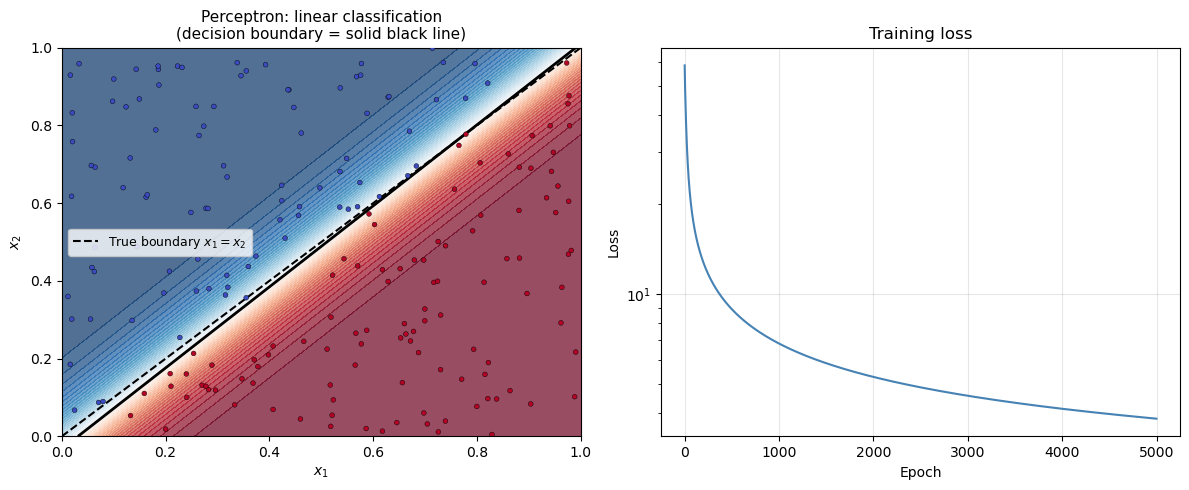

In [3]:
np.random.seed(0)
X_lin = np.random.rand(200, 2)
y_lin = (X_lin[:, 0] > X_lin[:, 1]).astype(float).reshape(-1, 1)

model_lin = Perceptron(2, 1)
model_lin.train(X_lin, y_lin, epochs=5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_decision_boundary(model_lin, X_lin, y_lin, axes[0],
                       'Perceptron: linear classification\n(decision boundary = solid black line)')
# Show the true boundary for reference
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='True boundary $x_1=x_2$')
axes[0].legend(fontsize=9)

axes[1].semilogy(model_lin.loss_history, linewidth=1.5, color='steelblue')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

The perceptron finds the correct linear boundary. Now let's make the problem harder.

### Task 2: Quadrant classification (the perceptron fails)

Classify points as 1 if $x_1 > 0.5$ **or** $x_2 > 0.5$ — an L-shaped region. No single line can separate this; the true boundary has a corner. The perceptron can only draw one line, so it will do its best linear approximation and get stuck.

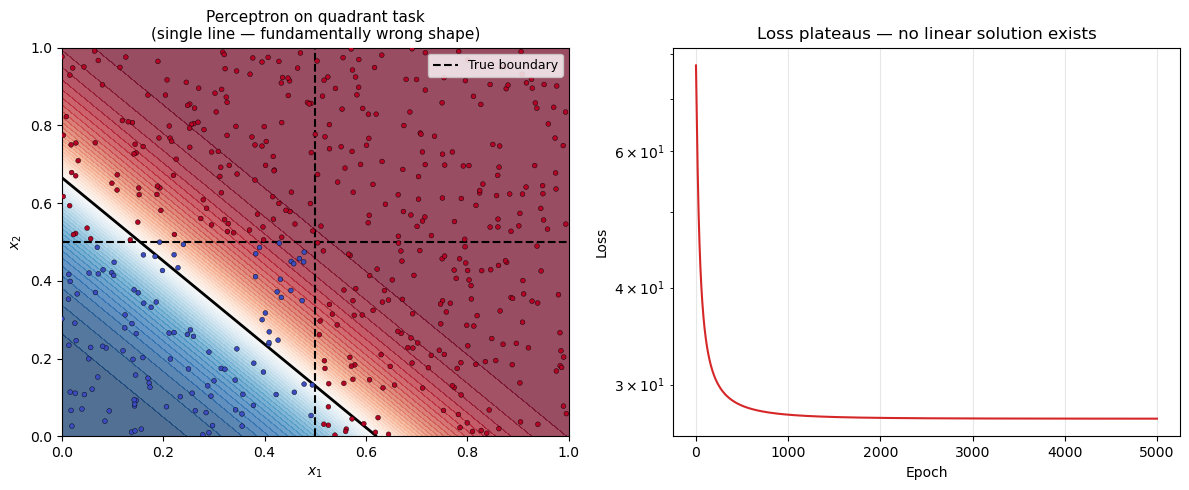

In [4]:
np.random.seed(1)
X_quad = np.random.rand(500, 2)
y_quad = np.zeros((500, 1))
y_quad[X_quad[:, 0] > 0.5] = 1
y_quad[X_quad[:, 1] > 0.5] = 1

model_quad_1 = Perceptron(2, 1)
model_quad_1.train(X_quad, y_quad, epochs=5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_decision_boundary(model_quad_1, X_quad, y_quad, axes[0],
                       'Perceptron on quadrant task\n(single line — fundamentally wrong shape)')
# Draw true boundary
axes[0].axvline(0.5, color='k', linestyle='--', linewidth=1.5, label='True boundary')
axes[0].axhline(0.5, color='k', linestyle='--', linewidth=1.5)
axes[0].legend(fontsize=9)

axes[1].semilogy(model_quad_1.loss_history, linewidth=1.5, color='C3')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss plateaus — no linear solution exists')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

The loss plateaus — gradient descent converges, but not to a good solution. The problem is not with the optimizer; it's with the **model class**. A perceptron can only represent a single hyperplane, and no hyperplane correctly classifies this data. We need a richer function class.

---
## 2. Activation Functions

The perceptron fails because stacking linear operations gives another linear operation. No matter how many linear layers we add:

$$
\mathbf{W}_2(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = \underbrace{(\mathbf{W}_2 \mathbf{W}_1)}_{\mathbf{W}'} \mathbf{x} + \underbrace{(\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2)}_{\mathbf{b}'}
$$

This is just another affine map. The **activation function** $\sigma$ is inserted *between* layers to break this collapse. Applied element-wise, it introduces nonlinearity that lets the composition represent curved decision boundaries.

Common choices and their trade-offs:

| Name | Formula | Range | Notes |
|------|---------|-------|-------|
| **Sigmoid** | $1/(1+e^{-z})$ | $(0,1)$ | Saturates for large $|z|$ → vanishing gradients |
| **Tanh** | $\tanh(z)$ | $(-1,1)$ | Zero-centered; still saturates |
| **ReLU** | $\max(0,z)$ | $[0,\infty)$ | Non-saturating; fast; "dying ReLU" at $z<0$ |
| **GELU** | $z\Phi(z)$ | $\mathbb{R}$ | Smooth ReLU; standard in modern transformers |

The derivative of $\sigma$ appears directly in backpropagation (BP equation 2 below). Saturation means $\sigma'(z) \approx 0$, which starves earlier layers of gradient signal — the **vanishing gradient problem**.

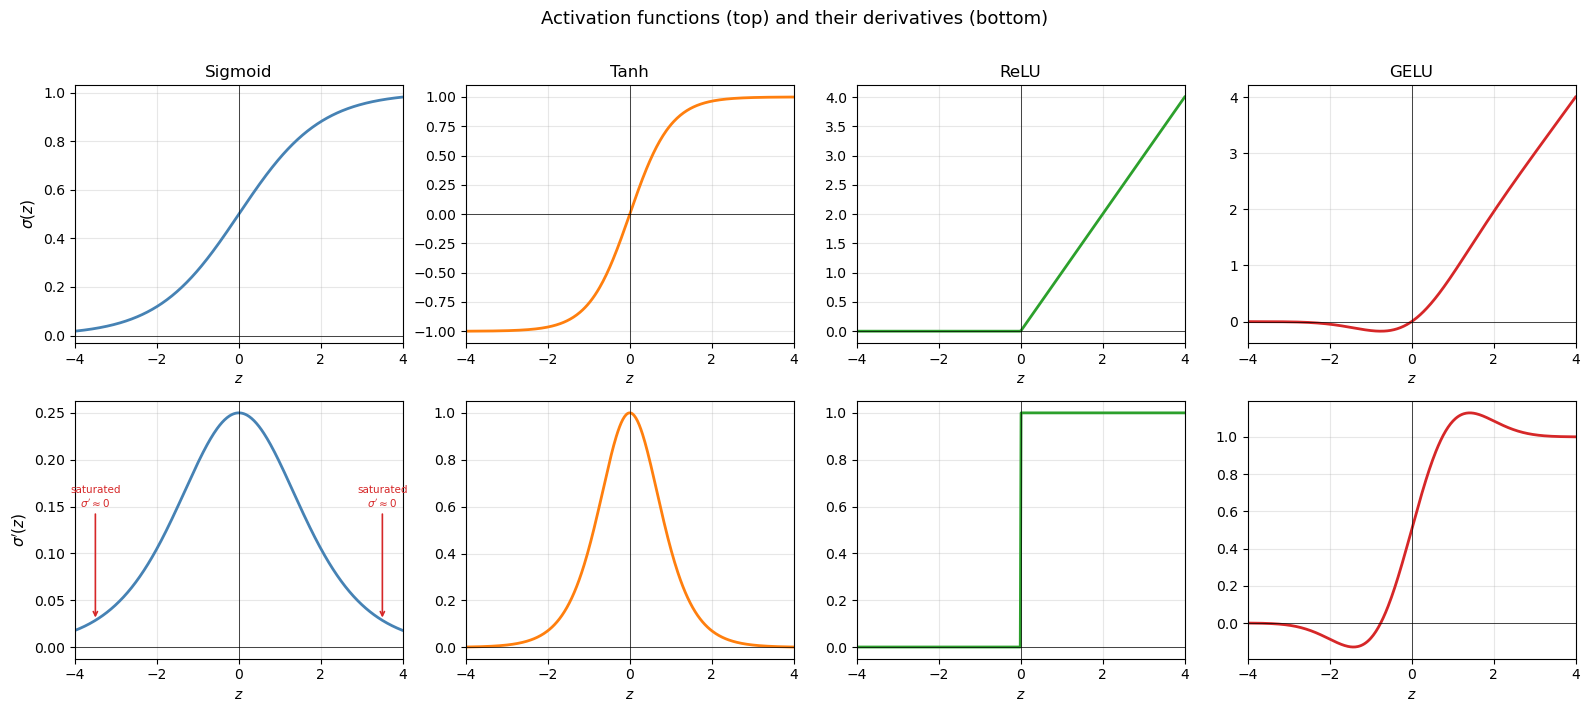

In [5]:
z = np.linspace(-4, 4, 400)

acts = {
    'Sigmoid': (sigmoid(z), d_sigmoid(z), 'steelblue'),
    'Tanh':    (np.tanh(z), 1 - np.tanh(z)**2, 'C1'),
    'ReLU':    (np.maximum(0, z), (z > 0).astype(float), 'C2'),
    'GELU':    (
        z * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3))),
        None,   # plotted separately
        'C3'
    ),
}

# GELU derivative (analytical approximation)
tanh_arg = np.sqrt(2/np.pi) * (z + 0.044715 * z**3)
tanh_val  = np.tanh(tanh_arg)
gelu_d    = 0.5*(1 + tanh_val) + z*0.5*(1-tanh_val**2)*np.sqrt(2/np.pi)*(1 + 3*0.044715*z**2)
acts['GELU'] = (acts['GELU'][0], gelu_d, 'C3')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col, (name, (f, df, c)) in enumerate(acts.items()):
    for row, (vals, ylabel) in enumerate([(f, '$\\sigma(z)$'), (df, "$\\sigma'(z)$")]):
        ax = axes[row, col]
        ax.plot(z, vals, color=c, linewidth=2)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.axvline(0, color='k', linewidth=0.5)
        ax.set_xlim(-4, 4)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('$z$')
        if col == 0: ax.set_ylabel(ylabel, fontsize=11)
    axes[0, col].set_title(name, fontsize=12)

# Annotate saturation regions on sigmoid
for z_sat, label in [(-3.5, 'saturated\n$\\sigma\'\\approx 0$'), (3.5, 'saturated\n$\\sigma\'\\approx 0$')]:
    axes[1, 0].annotate(label, xy=(z_sat, d_sigmoid(z_sat)),
                        xytext=(z_sat, 0.15), fontsize=7.5, ha='center', color='C3',
                        arrowprops=dict(arrowstyle='->', color='C3', lw=1.2))

plt.suptitle('Activation functions (top) and their derivatives (bottom)',
             fontsize=13, y=1.01)
plt.tight_layout()

---
## 3. Adding a Hidden Layer

The fix for the quadrant problem is to insert a **hidden layer**: a set of $d$ neurons that each compute a feature of the input, followed by a final linear combination of those features.

$$
\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) \in \mathbb{R}^d, \qquad
\hat{y} = \sigma(\mathbf{w}_2^T \mathbf{h} + b_2)
$$

Now the backward pass has two applications of the chain rule — one per layer. For the output layer (index 2) and hidden layer (index 1):

$$
\delta_2 = 2(\hat{y} - y) \cdot \sigma'(\mathbf{z}_2)
$$
$$
\frac{\partial \mathcal{L}}{\partial \mathbf{W}_2} = \mathbf{h}^T \delta_2, \qquad
\frac{\partial \mathcal{L}}{\partial \mathbf{b}_2} = \delta_2
$$
$$
\delta_1 = (\mathbf{W}_2^T \delta_2) \odot \sigma'(\mathbf{z}_1)
$$
$$
\frac{\partial \mathcal{L}}{\partial \mathbf{W}_1} = \mathbf{x}^T \delta_1, \qquad
\frac{\partial \mathcal{L}}{\partial \mathbf{b}_1} = \delta_1
$$

The error signal $\delta_\ell$ propagates **backwards** through the transpose of the weight matrix — hence the name backpropagation. We implement this explicitly below.

In [7]:
class SingleHiddenLayerNet:
    """One hidden layer, sigmoid activations, trained by explicit backprop."""

    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.W1 = np.random.rand(input_size, hidden_size)
        self.b1 = np.random.rand(hidden_size)
        self.W2 = np.random.rand(hidden_size, output_size)
        self.b2 = np.random.rand(output_size)
        self.lr = lr

    def forward(self, X):
        self.X  = X
        self.Z1 = X   @ self.W1 + self.b1;  self.A1 = sigmoid(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2;  self.A2 = sigmoid(self.Z2)
        return self.A2

    def backward(self, dA):
        # Output layer
        delta2 = dA * d_sigmoid(self.Z2)       # BP equation 1
        dW2    = self.A1.T @ delta2             # BP equation 3
        db2    = delta2.sum(axis=0)             # BP equation 4
        # Hidden layer — error propagated backward through W2^T
        delta1 = (delta2 @ self.W2.T) * d_sigmoid(self.Z1)   # BP equation 2
        dW1    = self.X.T @ delta1
        db1    = delta1.sum(axis=0)
        # Update
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1

    def train(self, X, y, epochs):
        self.loss_history = []
        for _ in range(epochs):
            A = self.forward(X)
            self.backward(2 * (A - y))
            self.loss_history.append(np.sum((A - y)**2))

### Back to the quadrant problem

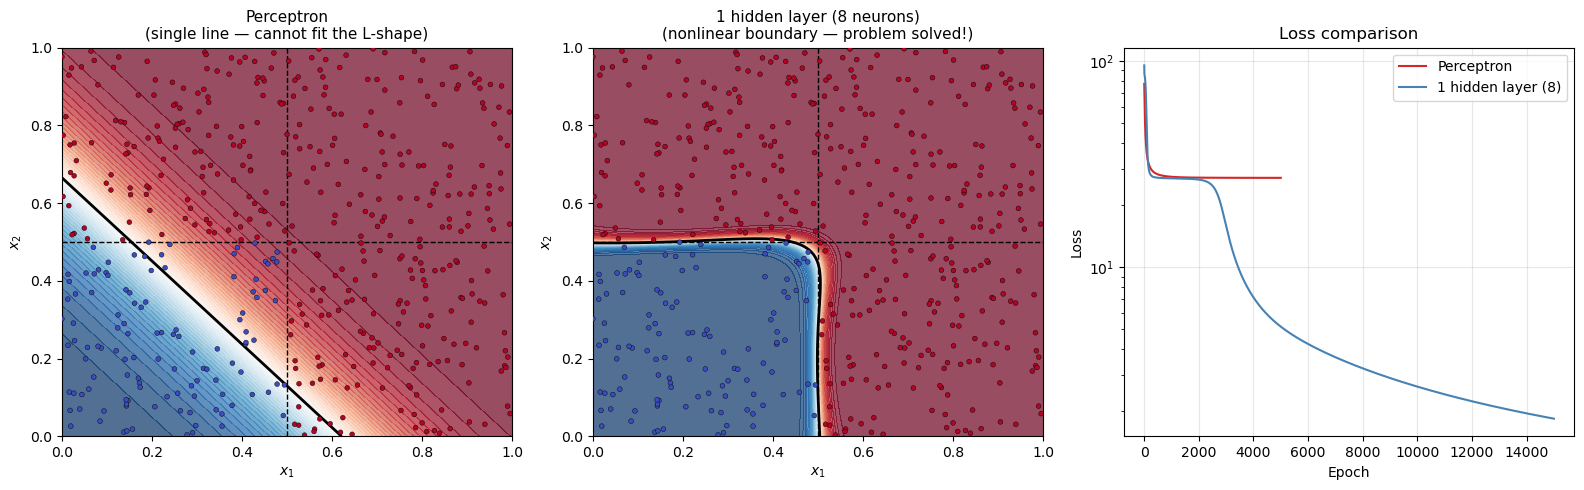

In [8]:
np.random.seed(2)
model_quad_2 = SingleHiddenLayerNet(2, 8, 1)
model_quad_2.train(X_quad, y_quad, epochs=15000)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Compare perceptron vs. single hidden layer on the quadrant task
plot_decision_boundary(model_quad_1, X_quad, y_quad, axes[0],
                       'Perceptron\n(single line — cannot fit the L-shape)')
axes[0].axvline(0.5, color='k', linestyle='--', linewidth=1)
axes[0].axhline(0.5, color='k', linestyle='--', linewidth=1)

plot_decision_boundary(model_quad_2, X_quad, y_quad, axes[1],
                       '1 hidden layer (8 neurons)\n(nonlinear boundary — problem solved!)')
axes[1].axvline(0.5, color='k', linestyle='--', linewidth=1)
axes[1].axhline(0.5, color='k', linestyle='--', linewidth=1)

axes[2].semilogy(model_quad_1.loss_history, label='Perceptron', color='C3', linewidth=1.5)
axes[2].semilogy(model_quad_2.loss_history, label='1 hidden layer (8)', color='steelblue', linewidth=1.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].set_title('Loss comparison')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()

The single hidden layer solves the quadrant problem. Let's push harder.

### Task 3: Annular ring

Now classify points as 1 if their radius $r = \|\mathbf{x}\|$ satisfies $r < 0.5$ or $r > 0.7$ — a ring-shaped region with a hole. The boundary is circular, not linear.

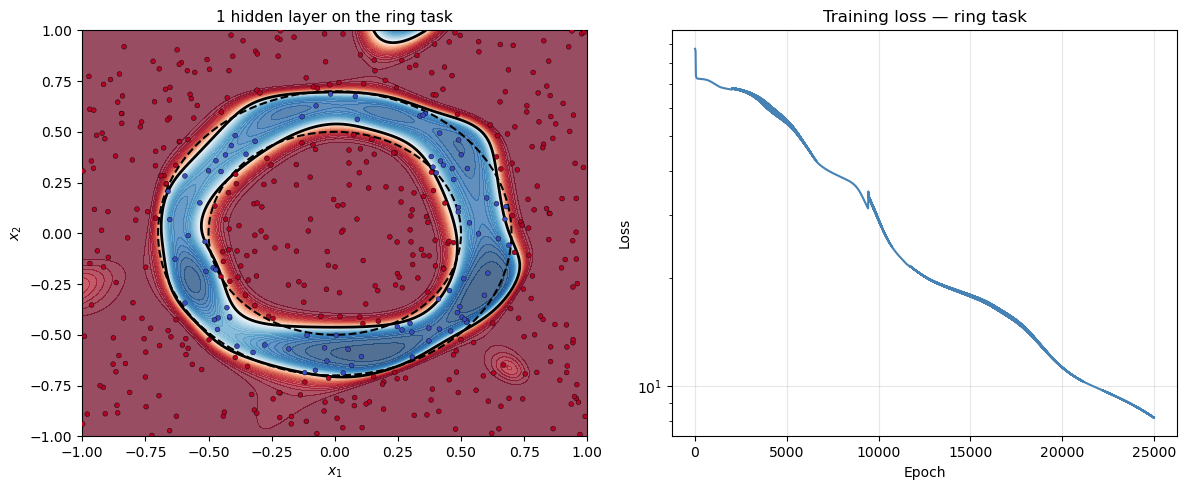

In [10]:
np.random.seed(3)
X_ring = 2 * (np.random.rand(500, 2) - 0.5)   # uniform in [-1, 1]^2
r_ring  = np.linalg.norm(X_ring, axis=1)
y_ring  = np.zeros((500, 1))
y_ring[(r_ring < 0.5) | (r_ring > 0.7)] = 1

np.random.seed(4)
model_ring = SingleHiddenLayerNet(2, 16, 1)
model_ring.train(X_ring, y_ring, epochs=25000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_decision_boundary(model_ring, X_ring, y_ring, axes[0],
                       '1 hidden layer on the ring task', grid_range=(-1, 1))
for r in [0.5, 0.7]:
    th = np.linspace(0, 2*np.pi, 300)
    axes[0].plot(r*np.cos(th), r*np.sin(th), 'k--', linewidth=1.5)

axes[1].semilogy(model_ring.loss_history, linewidth=1.5, color='steelblue')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training loss — ring task')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

The single hidden layer handles the circular boundary well. Now let's add one more twist: put a solid ball back in the center of the ring, so class 1 forms an **annular shell**. The boundary now has *two* concentric circles, and the correct class 1 region is topologically a shell — disjoint from both the inner ball and the outer region.

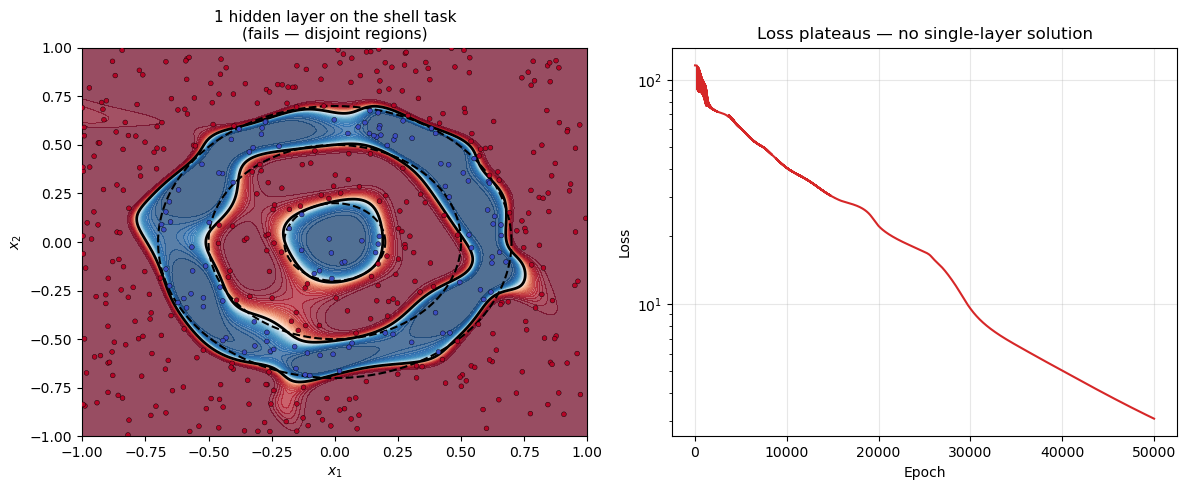

In [12]:
np.random.seed(5)
X_shell = 2 * (np.random.rand(500, 2) - 0.5)
r_shell  = np.linalg.norm(X_shell, axis=1)
y_shell  = np.zeros((500, 1))
y_shell[(r_shell < 0.5) | (r_shell > 0.7)] = 1
y_shell[r_shell < 0.2] = 0                     # ← inner ball is class 0 again

np.random.seed(6)
model_shell_1 = SingleHiddenLayerNet(2, 32, 1)
model_shell_1.train(X_shell, y_shell, epochs=50000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_decision_boundary(model_shell_1, X_shell, y_shell, axes[0],
                       '1 hidden layer on the shell task\n(fails — disjoint regions)', grid_range=(-1, 1))
for r in [0.2, 0.5, 0.7]:
    th = np.linspace(0, 2*np.pi, 300)
    axes[0].plot(r*np.cos(th), r*np.sin(th), 'k--', linewidth=1.5)

axes[1].semilogy(model_shell_1.loss_history, linewidth=1.5, color='C3')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss plateaus — no single-layer solution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

The single hidden layer cannot correctly represent this boundary. It finds a compromise but the inner ball and the outer region remain confused. The problem is **topological**: the class 1 region (the shell) is disconnected from the boundaries in a way that a shallow network cannot resolve without being much wider.

---
## 4. Going Deeper: The Multilayer Perceptron

The fix is to add another hidden layer. The full **Multilayer Perceptron (MLP)** with $L$ hidden layers is:

$$
\mathbf{h}^{(0)} = \mathbf{x}, \qquad
\mathbf{h}^{(\ell)} = \sigma\!\left(\mathbf{W}^{(\ell)} \mathbf{h}^{(\ell-1)} + \mathbf{b}^{(\ell)}\right), \quad \ell = 1,\ldots,L
$$

The backpropagation pattern generalizes: define $\boldsymbol{\delta}^{(\ell)} = \partial\mathcal{L}/\partial\mathbf{z}^{(\ell)}$. Then for each layer going backwards:

$$
\boldsymbol{\delta}^{(\ell)} = \left[(\mathbf{W}^{(\ell+1)})^T \boldsymbol{\delta}^{(\ell+1)}\right] \odot \sigma'(\mathbf{z}^{(\ell)})
$$

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(\ell)}} = \boldsymbol{\delta}^{(\ell)} (\mathbf{h}^{(\ell-1)})^T, \qquad
\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(\ell)}} = \boldsymbol{\delta}^{(\ell)}
$$

The structure is the same at every layer — just one more application of the chain rule. The code below shows this pattern made explicit for 2 hidden layers.

In [13]:
class TwoHiddenLayerNet:
    """Two hidden layers, sigmoid activations, explicit backprop."""

    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.W1 = np.random.rand(input_size,  hidden_size)
        self.b1 = np.random.rand(hidden_size)
        self.W2 = np.random.rand(hidden_size, hidden_size)
        self.b2 = np.random.rand(hidden_size)
        self.W3 = np.random.rand(hidden_size, output_size)
        self.b3 = np.random.rand(output_size)
        self.lr = lr

    def forward(self, X):
        self.X  = X
        self.Z1 = X      @ self.W1 + self.b1;  self.A1 = sigmoid(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2;  self.A2 = sigmoid(self.Z2)
        self.Z3 = self.A2 @ self.W3 + self.b3;  self.A3 = sigmoid(self.Z3)
        return self.A3

    def backward(self, dA):
        # Layer 3 (output)
        d3 = dA * d_sigmoid(self.Z3)
        dW3 = self.A2.T @ d3;   db3 = d3.sum(0)
        # Layer 2 — BP eq. 2: propagate through W3^T
        d2 = (d3 @ self.W3.T) * d_sigmoid(self.Z2)
        dW2 = self.A1.T @ d2;   db2 = d2.sum(0)
        # Layer 1 — BP eq. 2: propagate through W2^T
        d1 = (d2 @ self.W2.T) * d_sigmoid(self.Z1)
        dW1 = self.X.T  @ d1;   db1 = d1.sum(0)
        # Update all layers
        for (W, dW, b, db) in [(self.W3, dW3, self.b3, db3),
                                (self.W2, dW2, self.b2, db2),
                                (self.W1, dW1, self.b1, db1)]:
            W -= self.lr * dW
            b -= self.lr * db

    def train(self, X, y, epochs):
        self.loss_history = []
        for _ in range(epochs):
            A = self.forward(X)
            self.backward(2 * (A - y))
            self.loss_history.append(np.sum((A - y)**2))

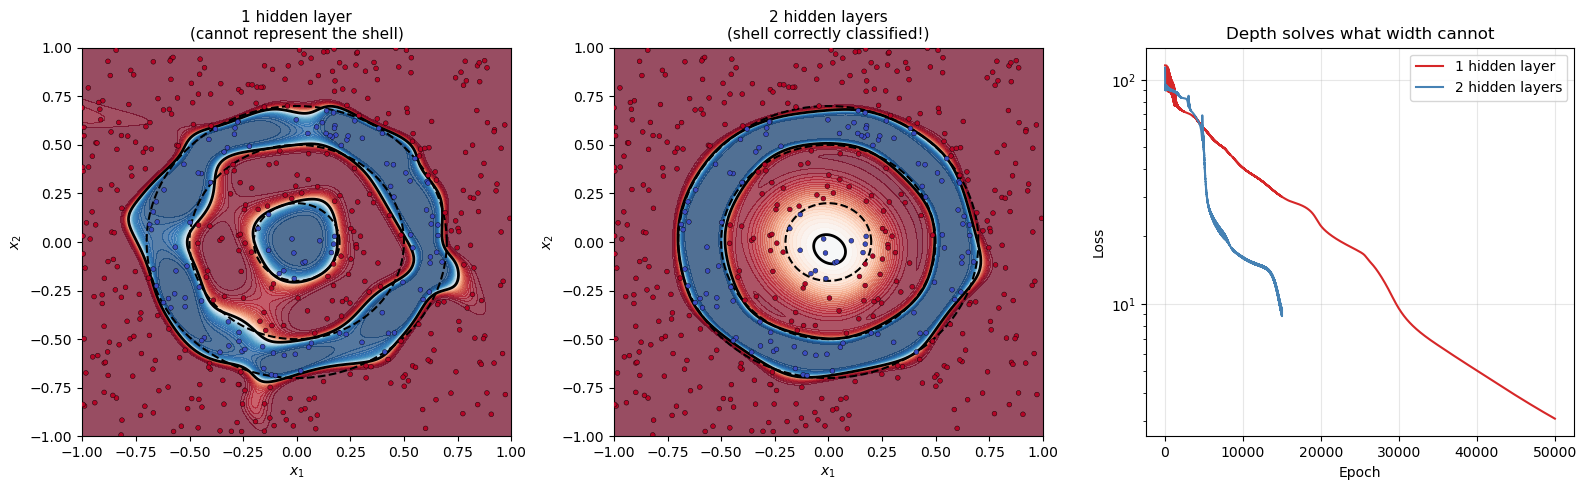

In [14]:
np.random.seed(7)
model_shell_2 = TwoHiddenLayerNet(2, 8, 1)
model_shell_2.train(X_shell, y_shell, epochs=15000)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_decision_boundary(model_shell_1, X_shell, y_shell, axes[0],
                       '1 hidden layer\n(cannot represent the shell)', grid_range=(-1, 1))
plot_decision_boundary(model_shell_2, X_shell, y_shell, axes[1],
                       '2 hidden layers\n(shell correctly classified!)', grid_range=(-1, 1))
for ax in axes[:2]:
    for r in [0.2, 0.5, 0.7]:
        th = np.linspace(0, 2*np.pi, 300)
        ax.plot(r*np.cos(th), r*np.sin(th), 'k--', linewidth=1.5)

axes[2].semilogy(model_shell_1.loss_history, label='1 hidden layer', color='C3',       linewidth=1.5)
axes[2].semilogy(model_shell_2.loss_history, label='2 hidden layers', color='steelblue', linewidth=1.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].set_title('Depth solves what width cannot')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()

With two hidden layers, the network correctly identifies the shell. Depth enables hierarchical composition: the first hidden layer learns to detect proximity to each of the three radii; the second layer combines those detections into the correct topology.

This is the core lesson:

| Architecture | Can represent | Cannot represent |
|---|---|---|
| No hidden layer (perceptron) | Half-planes | Any curved boundary |
| 1 hidden layer | Any connected nonlinear region | Topologically complex (disjoint) regions without extreme width |
| 2+ hidden layers | Complex, disjoint, hierarchical structures | — (with sufficient width) |

---
## 5. Automatic Differentiation

We implemented `backward()` by hand for each architecture above. This is instructive, but scales poorly — every architecture change requires rewriting the gradient code. Real networks have hundreds of layers and many non-standard operations.

**Automatic differentiation (AD)** computes exact gradients through any differentiable computation by applying the chain rule automatically. It is *not* symbolic differentiation (too slow for large programs) and it is *not* finite differences (inaccurate; requires $O(n_{\text{params}})$ function evaluations). AD operates directly on numerical values, tracking derivative information alongside each elementary operation.

### The computational graph for $f(x) = \sin(x^2) + \cos(x^2)$

Any computation can be broken down into a **directed acyclic graph (DAG)** of primitive operations — each of which has a known local derivative. For $f(x) = \sin(x^2) + \cos(x^2)$, the intermediate nodes are:

$$
c_1 = x^2, \quad c_2 = x^2, \quad c_3 = \cos(c_1), \quad c_4 = \sin(c_2), \quad c_5 = c_3 + c_4 = f
$$

<div style="text-align:center">
<img src="assets/computational_graph.png" width="500" alt="Computational graph for sin(x^2)+cos(x^2)">
</div>

### Forward mode: propagate tangents left-to-right

Set the seed $\dot{x} = dx/dx = 1$. At each node, compute both the value and its derivative:

$$
\dot{c}_1 = 2x, \quad
\dot{c}_3 = -\sin(c_1)\cdot\dot{c}_1 = -2x\sin(x^2), \quad
\dot{c}_4 = \cos(c_2)\cdot\dot{c}_2 = 2x\cos(x^2)
$$
$$
\dot{f} = \dot{c}_3 + \dot{c}_4 = 2x(\cos(x^2) - \sin(x^2))
$$

At $x = \pi$: $\dot{f}(\pi) = 2\pi(\cos(\pi^2) - \sin(\pi^2)) \approx -2.97$. One forward pass gives $df/dx$ for one input variable.

### Reverse mode: propagate adjoints right-to-left

Start from $\bar{f} = \partial f / \partial f = 1$ and work backwards:

$$
\frac{\partial f}{\partial x} = \frac{\partial f}{\partial c_5}\left(\frac{\partial c_5}{\partial c_4}\frac{\partial c_4}{\partial c_2}\frac{\partial c_2}{\partial x} + \frac{\partial c_5}{\partial c_3}\frac{\partial c_3}{\partial c_1}\frac{\partial c_1}{\partial x}\right) = 2x(\cos(x^2) - \sin(x^2))
$$

One backward pass gives $\partial \mathcal{L}/\partial \theta_j$ for **all** parameters $\theta_j$ simultaneously — this is why reverse mode is used for training neural networks.

| | Forward mode | Reverse mode |
|---|---|---|
| Cost | $O(n_{\text{in}})$ passes for full gradient | $O(n_{\text{out}})$ passes for full gradient |
| Best for | Few inputs, many outputs | **Few outputs (scalar loss), many inputs** ← neural nets |
| PyTorch API | `torch.autograd.functional.jvp` | **`.backward()`** |

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd.functional import jacobian
torch.manual_seed(42)

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.7.1


Max |autograd - analytic|: 8.88e-16


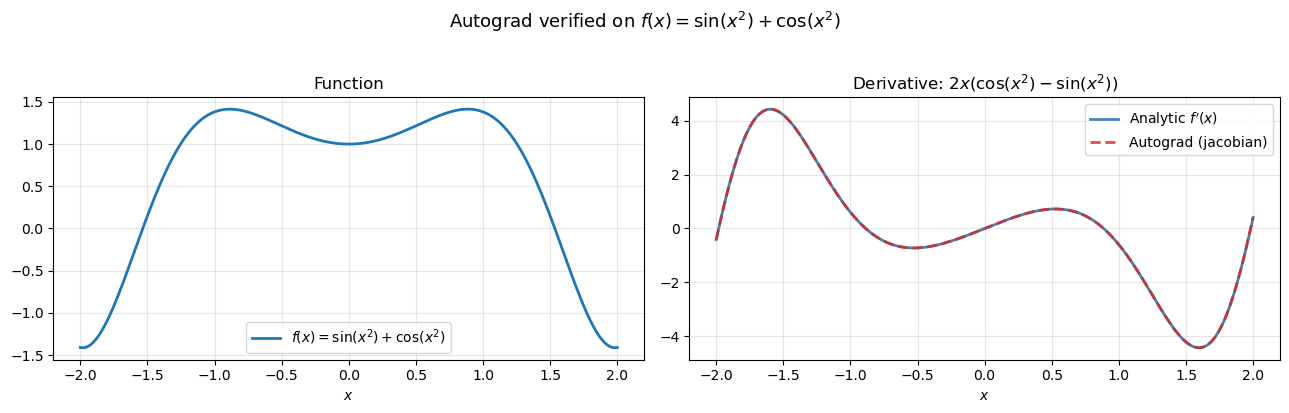

In [16]:
# f(x) = sin(x^2) + cos(x^2)
# Analytic derivative: df/dx = 2x(cos(x^2) - sin(x^2))
def f_sincos(x):
    return torch.sin(x**2) + torch.cos(x**2)

def df_sincos_analytic(x):
    return 2*x*(torch.cos(x**2) - torch.sin(x**2))

# Evaluate on a grid using torch.autograd.functional.jacobian
# (for scalar-valued f, the Jacobian is just the derivative)
v = torch.linspace(-2, 2, 200, dtype=torch.float64)
df_autograd = torch.stack([jacobian(f_sincos, vv) for vv in v])
df_analytic = df_sincos_analytic(v)

print(f'Max |autograd - analytic|: {(df_autograd - df_analytic).abs().max():.2e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(v.numpy(), f_sincos(v).detach().numpy(),
             linewidth=2, label='$f(x) = \\sin(x^2)+\\cos(x^2)$')
axes[0].set_xlabel('$x$'); axes[0].set_title('Function')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(v.numpy(), df_analytic.detach().numpy(),
             linewidth=2, label='Analytic $f\'(x)$', color='steelblue')
axes[1].plot(v.numpy(), df_autograd.detach().numpy(),
             linewidth=2, linestyle='--', label='Autograd (jacobian)',
             color='C3', alpha=0.8)
axes[1].set_xlabel('$x$')
axes[1].set_title('Derivative: $2x(\\cos(x^2) - \\sin(x^2))$')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Autograd verified on $f(x) = \\sin(x^2)+\\cos(x^2)$',
             fontsize=13, y=1.02)
plt.tight_layout()

In [18]:
# f(x, y) = sin(x*y) + exp(-x^2)
# Analytic: df/dx = y*cos(xy) - 2x*exp(-x^2),  df/dy = x*cos(xy)

x0, y0 = 0.5, 2.0
dfdx_exact = y0 * np.cos(x0*y0) - 2*x0 * np.exp(-x0**2)
dfdy_exact = x0 * np.cos(x0*y0)

# PyTorch autograd
x_t = torch.tensor(x0, requires_grad=True, dtype=torch.float64)
y_t = torch.tensor(y0, requires_grad=True, dtype=torch.float64)

f_t = torch.sin(x_t * y_t) + torch.exp(-x_t**2)  # forward: builds the graph
f_t.backward()                                      # reverse-mode AD

print('f(x,y) = sin(x*y) + exp(-x²)  at  (x, y) = (0.5, 2.0)\n')
print(f'  df/dx  analytic:  {dfdx_exact:.10f}')
print(f'  df/dx  autograd:  {x_t.grad.item():.10f}')
print(f'  |error|:          {abs(x_t.grad.item() - dfdx_exact):.2e}  (≈ machine precision)\n')
print(f'  df/dy  analytic:  {dfdy_exact:.10f}')
print(f'  df/dy  autograd:  {y_t.grad.item():.10f}')
print(f'  |error|:          {abs(y_t.grad.item() - dfdy_exact):.2e}')

f(x,y) = sin(x*y) + exp(-x²)  at  (x, y) = (0.5, 2.0)

  df/dx  analytic:  0.3018038287
  df/dx  autograd:  0.3018038287
  |error|:          0.00e+00  (≈ machine precision)

  df/dy  analytic:  0.2701511529
  df/dy  autograd:  0.2701511529
  |error|:          0.00e+00


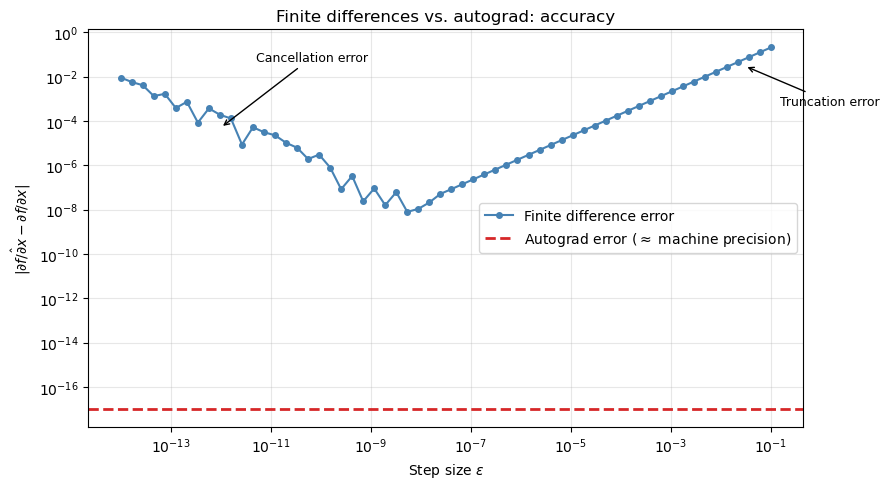

In [19]:
# Finite differences vs autograd: the accuracy-stability tradeoff
epsilons  = np.logspace(-1, -14, 60)
fd_errors = []
for eps in epsilons:
    f_p = np.sin((x0+eps)*y0) + np.exp(-(x0+eps)**2)
    f_0 = np.sin(x0*y0)       + np.exp(-x0**2)
    fd_errors.append(abs((f_p - f_0)/eps - dfdx_exact))

ag_err = abs(x_t.grad.item() - dfdx_exact)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(epsilons, fd_errors, 'o-', color='steelblue', markersize=4,
          label='Finite difference error', linewidth=1.5)
ax.axhline(max(ag_err, 1e-17), color='C3', linewidth=2, linestyle='--',
           label='Autograd error ($\\approx$ machine precision)')
ax.set_xlabel('Step size $\\epsilon$')
ax.set_ylabel('$|\\hat{\\partial f/\\partial x} - \\partial f/\\partial x|$')
ax.set_title('Finite differences vs. autograd: accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
ax.annotate('Truncation error', xy=(3e-2, 3e-2),
            xytext=(1.5e-1, 5e-4), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='k'))
ax.annotate('Cancellation error', xy=(1e-12, 5e-5),
            xytext=(5e-12, 5e-2), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='k'))
plt.tight_layout()

Finite differences have a fundamental tradeoff: large $\epsilon$ → truncation error; small $\epsilon$ → floating-point cancellation. Autograd avoids both. More importantly, finite differences require **one forward pass per parameter** to compute a full gradient, while autograd computes gradients with respect to all parameters in a single backward pass.

### The computation graph

PyTorch records every operation on `requires_grad=True` tensors as nodes in a graph. Each node stores its local derivative rule. The `.grad_fn` attribute exposes this:

In [20]:
x_g = torch.tensor(x0, requires_grad=True, dtype=torch.float64)
y_g = torch.tensor(y0, requires_grad=True, dtype=torch.float64)

v1 = x_g * y_g;        # MulBackward
v2 = torch.sin(v1);    # SinBackward
v3 = x_g ** 2;         # PowBackward
v4 = -v3;              # NegBackward
v5 = torch.exp(v4);    # ExpBackward
f_g = v2 + v5          # AddBackward

print('Computation graph — grad_fn at each node:')
print(f'  f    → {f_g.grad_fn.__class__.__name__}  (add v2 and v5)')
print(f'  v2   → {v2.grad_fn.__class__.__name__}   (sin of v1)')
print(f'  v1   → {v1.grad_fn.__class__.__name__}   (x × y)')
print(f'  v5   → {v5.grad_fn.__class__.__name__}   (exp of v4)')
print(f'  v4   → {v4.grad_fn.__class__.__name__}   (negate v3)')
print(f'  v3   → {v3.grad_fn.__class__.__name__}   (x²)')
print()
print('f.backward() walks this graph right-to-left, accumulating df/dx and df/dy')
print('using each node\'s stored local derivative rule.')

Computation graph — grad_fn at each node:
  f    → AddBackward0  (add v2 and v5)
  v2   → SinBackward0   (sin of v1)
  v1   → MulBackward0   (x × y)
  v5   → ExpBackward0   (exp of v4)
  v4   → NegBackward0   (negate v3)
  v3   → PowBackward0   (x²)

f.backward() walks this graph right-to-left, accumulating df/dx and df/dy
using each node's stored local derivative rule.


### Verifying autograd on activation functions

A good sanity-check habit: before trusting autograd in a complex model, verify it on simple functions whose derivatives you know analytically. The `torch.autograd.functional.jacobian` function computes $\partial f / \partial x$ for any scalar-valued $f$.

**ReLU**: $\text{ReLU}(x) = \max(0,x)$, so $\text{ReLU}'(x) = \mathbf{1}_{x>0}$

**Tanh**: $\tanh(x)$, so $\tanh'(x) = 1/\cosh^2(x) = 1 - \tanh^2(x)$

ReLU derivative: max |autograd - analytic| = 0.0
Tanh derivative: max |autograd - analytic| = 1.7881393432617188e-07


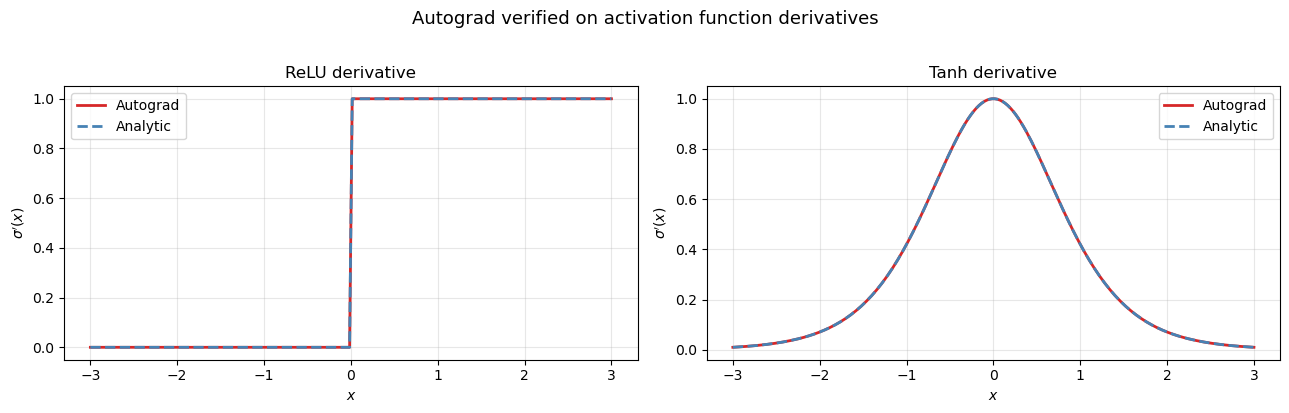

In [21]:
dtype = torch.float32
v32 = torch.linspace(-3, 3, 200, dtype=dtype)

# ── Analytic derivatives ──────────────────────────────────────────────
def drelu_analytic(x):  return (x > 0).float()
def dtanh_analytic(x):  return 1 / torch.cosh(x)**2

# ── Autograd via jacobian ─────────────────────────────────────────────
drelu_auto = torch.stack([jacobian(F.relu,       vv) for vv in v32])
dtanh_auto = torch.stack([jacobian(torch.tanh,   vv) for vv in v32])

drelu_true = drelu_analytic(v32)
dtanh_true = dtanh_analytic(v32)

print('ReLU derivative: max |autograd - analytic| =',
      (drelu_auto - drelu_true).abs().max().item())
print('Tanh derivative: max |autograd - analytic| =',
      (dtanh_auto - dtanh_true).abs().max().item())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, func, auto, true, name in [
    (axes[0], F.relu,     drelu_auto, drelu_true, 'ReLU'),
    (axes[1], torch.tanh, dtanh_auto, dtanh_true, 'Tanh'),
]:
    ax.plot(v32, auto.detach(), linewidth=2, label='Autograd',  color='C3')
    ax.plot(v32, true.detach(), linewidth=2, linestyle='--', label='Analytic', color='steelblue')
    ax.set_xlabel('$x$'); ax.set_ylabel("$\\sigma'(x)$")
    ax.set_title(f'{name} derivative'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Autograd verified on activation function derivatives', fontsize=13, y=1.02)
plt.tight_layout()

### Chain rule through networks

The same `jacobian` function works for any `nn.Module`. Here we verify autograd on two network architectures whose derivatives we can derive by hand:

**Single neuron** (identity weights, no bias): $f(x) = \tanh(x)$, so $f'(x) = 1/\cosh^2(x)$

**Two-layer composition**: $f(x) = \tanh(\text{ReLU}(x))$

By the chain rule: $f'(x) = \tanh'(\text{ReLU}(x)) \cdot \text{ReLU}'(x) = \frac{1}{\cosh^2(\text{ReLU}(x))} \cdot \mathbf{1}_{x>0}$

Note that for $x \leq 0$, $\text{ReLU}(x) = 0$ so $\tanh(\text{ReLU}(x)) = \tanh(0) = 0$ for all $x \leq 0$, and the derivative is zero.

1-layer (tanh):       max |error| = 1.79e-07
2-layer (relu+tanh):  max |error| = 1.79e-07


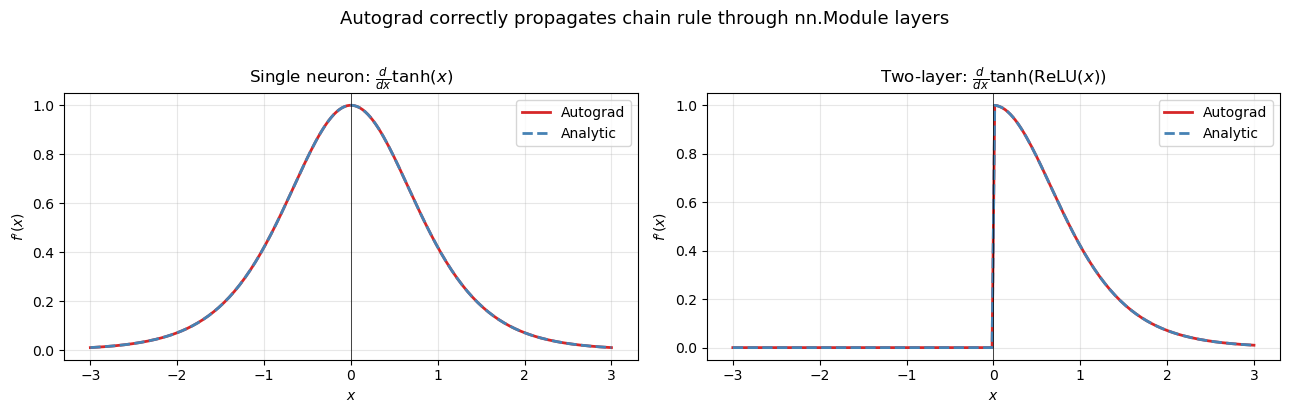

In [22]:
class Neuron(nn.Module):
    """Single neuron with configurable activation. Default: identity weight, zero bias."""
    def __init__(self, activation=nn.Tanh):
        super().__init__()
        self.layer = nn.Linear(1, 1)
        self.act   = activation()
        with torch.no_grad():
            self.layer.weight[:] = 1.0
            self.layer.bias[:]   = 0.0

    def forward(self, x):
        return self.act(self.layer(x))


# Single neuron: f(x) = tanh(x)
m1 = Neuron(nn.Tanh)
dm1_auto = torch.stack([
    jacobian(m1, vv.view(-1, 1)).squeeze() for vv in v32
])
dm1_true = dtanh_analytic(v32)

# Two-layer: f(x) = tanh(ReLU(x))
m2 = nn.Sequential(Neuron(nn.ReLU), Neuron(nn.Tanh))
dm2_auto = torch.stack([
    jacobian(m2, vv.view(-1, 1)).squeeze() for vv in v32
])
dm2_true = drelu_analytic(v32) * dtanh_analytic(F.relu(v32))

print(f'1-layer (tanh):       max |error| = {(dm1_auto - dm1_true).abs().max():.2e}')
print(f'2-layer (relu+tanh):  max |error| = {(dm2_auto - dm2_true).abs().max():.2e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, auto, true, title in [
    (axes[0], dm1_auto, dm1_true, r'Single neuron: $\frac{d}{dx}\tanh(x)$'),
    (axes[1], dm2_auto, dm2_true, r'Two-layer: $\frac{d}{dx}\tanh(\mathrm{ReLU}(x))$'),
]:
    ax.plot(v32, auto.detach(), linewidth=2, label='Autograd', color='C3')
    ax.plot(v32, true.detach(), linewidth=2, linestyle='--', label='Analytic', color='steelblue')
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_xlabel('$x$'); ax.set_ylabel("$f'(x)$")
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Autograd correctly propagates chain rule through nn.Module layers',
             fontsize=13, y=1.02)
plt.tight_layout()

### Autograd beyond neural networks

Because AD works through *any* differentiable computation — not just `nn.Module` layers — it can be used anywhere a derivative is needed. A classic example is **Newton's method** for root-finding:

$$
x^{(i+1)} = x^{(i)} - \frac{f(x^{(i)})}{f'(x^{(i)})}
$$

Instead of supplying an analytic derivative, we let autograd compute $f'(x^{(i)})$ automatically. This is how **physics-informed neural networks (PINNs)** work: the PDE residual is a loss term, and the spatial/temporal derivatives of the network output are computed via autograd — no finite differences, no symbolic differentiation.

Below we find the root of $f(x) = x^3 - 2x - 5$ (analytic root: $x \approx 2.0946$).

Newton converged in 4 iterations
Root: x = 2.09455148  (analytic: ~2.09455148)
f(x) = 1.74e-09


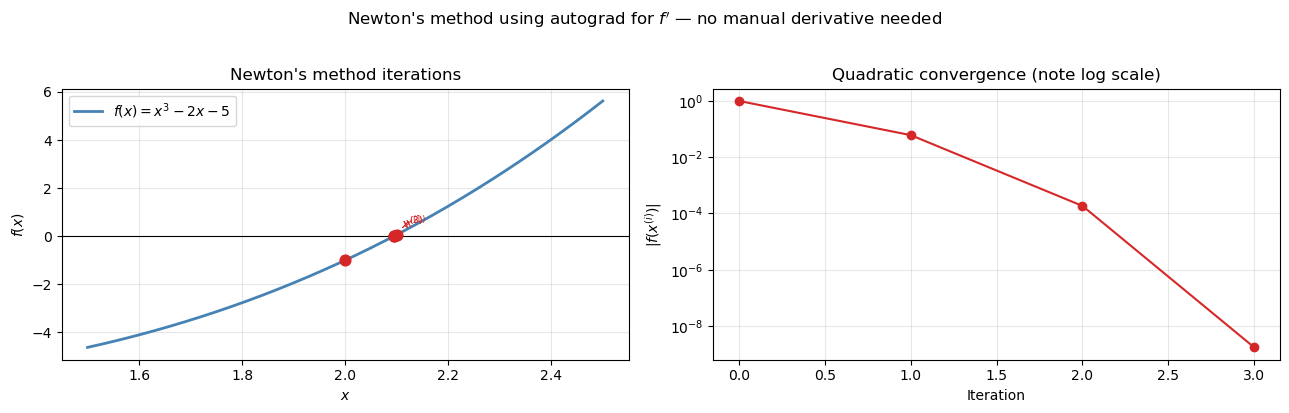

In [23]:
def newton_solve(f, x_init, tol=1e-6, max_iter=50):
    """Newton's method with autograd-computed derivative."""
    x = torch.tensor(x_init, dtype=torch.float64, requires_grad=True)
    history = []
    for _ in range(max_iter):
        fx = f(x)
        history.append((x.item(), fx.item()))
        if fx.abs().item() < tol:
            break
        # Autograd computes f'(x) without us writing it out
        grad_x = torch.autograd.grad(fx, x)[0]
        with torch.no_grad():
            x = (x - fx / grad_x).detach().requires_grad_(True)
    return x, history


def f_cubic(x):
    return x**3 - 2*x - 5

x_root, hist = newton_solve(f_cubic, x_init=2.0)
print(f'Newton converged in {len(hist)} iterations')
print(f'Root: x = {x_root.item():.8f}  (analytic: ~2.09455148)')
print(f'f(x) = {f_cubic(x_root).item():.2e}')

# Plot convergence
x_plot = torch.linspace(1.5, 2.5, 300, dtype=torch.float64)
y_plot = f_cubic(x_plot).detach()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_plot, y_plot, linewidth=2, color='steelblue', label='$f(x) = x^3 - 2x - 5$')
axes[0].axhline(0, color='k', linewidth=0.8)
for i, (xi, fi) in enumerate(hist):
    axes[0].scatter(xi, fi, color='C3', s=60, zorder=5)
    if i > 0:
        axes[0].annotate(f'$x^{{({i})}}$', (xi, fi), textcoords='offset points',
                         xytext=(5, 5), fontsize=9, color='C3')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$f(x)$')
axes[0].set_title("Newton's method iterations")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy([abs(fi) for (_, fi) in hist], 'o-', color='C3', linewidth=1.5)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('$|f(x^{(i)})|$')
axes[1].set_title('Quadratic convergence (note log scale)')
axes[1].grid(True, alpha=0.3)

plt.suptitle("Newton's method using autograd for $f'$ — no manual derivative needed",
             fontsize=12, y=1.02)
plt.tight_layout()

---
## 6. Backpropagation: Verified

The explicit `backward()` methods we wrote in sections 3–4 are exactly what PyTorch's autograd executes under the hood. We can verify this by comparing our manual gradients against `.backward()` for the same network.

In [24]:
# Use the same single-layer architecture to compare manual vs autograd gradients
torch.manual_seed(0)

n_in, n_hid, n_out = 2, 8, 1

# Shared parameters (convert from numpy model to torch)
np.random.seed(2)
W1_np = np.random.rand(n_in,  n_hid)
b1_np = np.random.rand(n_hid)
W2_np = np.random.rand(n_hid, n_out)
b2_np = np.random.rand(n_out)

# A single batch
x_bp = torch.tensor(X_quad[:5], dtype=torch.float64)   # 5 samples
y_bp = torch.tensor(y_quad[:5], dtype=torch.float64)

# ── Manual forward + backward ──
m_manual = SingleHiddenLayerNet(n_in, n_hid, n_out)
m_manual.W1, m_manual.b1 = W1_np.copy(), b1_np.copy()
m_manual.W2, m_manual.b2 = W2_np.copy(), b2_np.copy()

x_np = X_quad[:5]
A_man = m_manual.forward(x_np)
# Store gradients before the update step
dA_man = 2 * (A_man - y_quad[:5])
delta2 = dA_man * d_sigmoid(m_manual.Z2)
dW2_man = m_manual.A1.T @ delta2
delta1  = (delta2 @ m_manual.W2.T) * d_sigmoid(m_manual.Z1)
dW1_man = x_np.T @ delta1

# ── PyTorch autograd ──
W1_ag = torch.tensor(W1_np, requires_grad=True, dtype=torch.float64)
b1_ag = torch.tensor(b1_np, requires_grad=True, dtype=torch.float64)
W2_ag = torch.tensor(W2_np, requires_grad=True, dtype=torch.float64)
b2_ag = torch.tensor(b2_np, requires_grad=True, dtype=torch.float64)

A1_ag  = torch.sigmoid(x_bp @ W1_ag + b1_ag)
A2_ag  = torch.sigmoid(A1_ag @ W2_ag + b2_ag)
loss_ag = ((A2_ag - y_bp)**2).sum()
loss_ag.backward()

print('Manual backprop vs. PyTorch autograd (max |error|):')
print(f'  dW1: {np.abs(dW1_man - W1_ag.grad.numpy()).max():.2e}')
print(f'  dW2: {np.abs(dW2_man - W2_ag.grad.numpy()).max():.2e}')
print()
print('Both compute identical gradients. PyTorch does this automatically')
print('for any architecture — no manual backward() needed.')

Manual backprop vs. PyTorch autograd (max |error|):
  dW1: 5.20e-18
  dW2: 1.11e-16

Both compute identical gradients. PyTorch does this automatically
for any architecture — no manual backward() needed.


---
## 7. The Training Process in PyTorch

With autograd handling the gradient computation, we can describe any network architecture using `nn.Sequential` or a custom `nn.Module` and train it with a standard loop.

### What is a sample?

The dataset is a collection of $(\mathbf{x}_i, y_i)$ pairs. What counts as a "sample" depends entirely on the problem:

| Task | $\mathbf{x}_i$ (input) | $y_i$ (target) |
|------|----------------------|----------------|
| Seasonal forecast | Atmospheric state at month $t$ | Rainfall at month $t+3$ |
| Emulating a parameterization | Temperature, humidity, wind profiles | Convective heating rates |
| Detecting cyclones | Satellite image patch | Cyclone / no cyclone |
| Learning equation structure | $(u(t), t)$ from ODE trajectory | $\dot{u}(t)$ |

The training loop has four steps, repeated every batch:
```
1. Forward:   ŷ = model(x)
2. Loss:      L = loss(ŷ, y)
3. Backward:  optimizer.zero_grad(); L.backward()
4. Update:    optimizer.step()
```
Step 3 requires `zero_grad()` first — PyTorch *accumulates* gradients by default, so without zeroing you add the new gradient on top of the old one.

### Train/validation split

Always split data into a **training set** (used for gradient updates), **validation set** (used to monitor generalization, never updated on), and **test set** (held out until final evaluation). For time-series Earth science data, this split must respect **temporal ordering** — never use future data to predict the past.

In [25]:
# Re-solve the shell classification task using PyTorch (compare to manual numpy version)
torch.manual_seed(99)

X_tr_t = torch.tensor(X_shell, dtype=torch.float32)
y_tr_t = torch.tensor(y_shell, dtype=torch.float32)

model_pt = nn.Sequential(
    nn.Linear(2, 16), nn.Sigmoid(),
    nn.Linear(16, 16), nn.Sigmoid(),
    nn.Linear(16, 1),  nn.Sigmoid(),
)

optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-2)
loss_fn   = nn.MSELoss()

pt_losses = []
for epoch in range(5000):
    y_pred = model_pt(X_tr_t)                # 1. forward
    loss   = loss_fn(y_pred, y_tr_t)         # 2. loss
    optimizer.zero_grad()                    # 3a. clear old gradients
    loss.backward()                          # 3b. backprop (autograd)
    optimizer.step()                         # 4. update
    pt_losses.append(loss.item())

print(f'Final loss: {pt_losses[-1]:.5f}')

Final loss: 0.00010


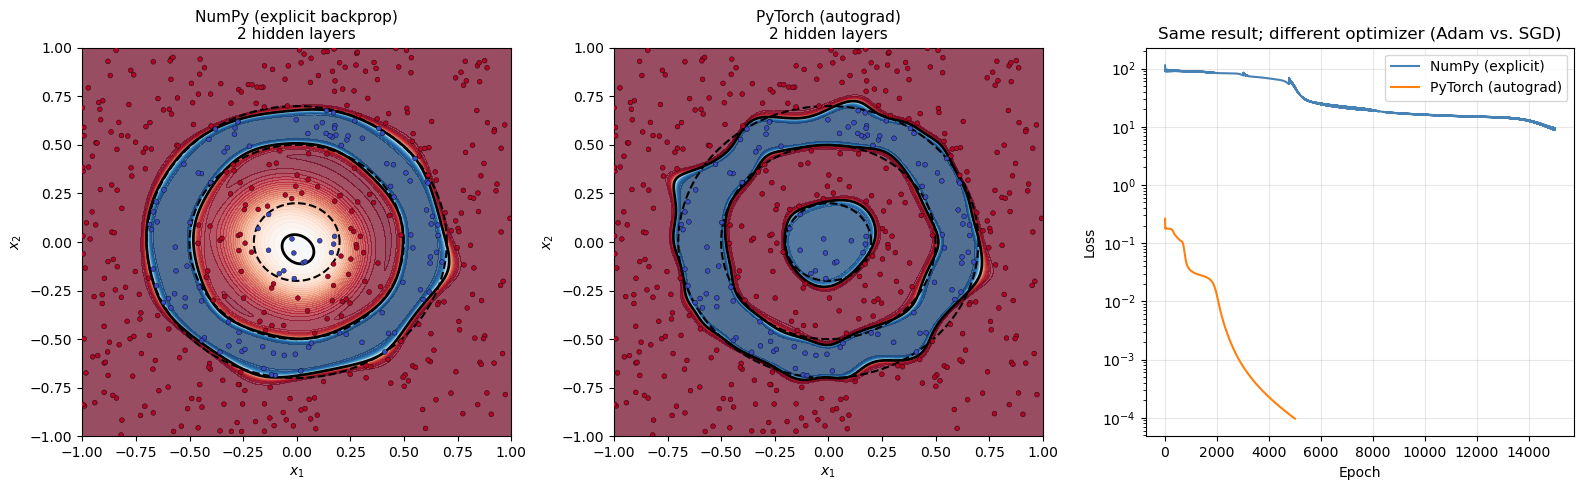

In [26]:
# Compare numpy (manual backprop) vs PyTorch (autograd) on the shell task
def pt_decision_boundary(model, X, y, ax, title, grid_range=(-1, 1), n_grid=300):
    lo, hi = grid_range
    xx = np.linspace(lo, hi, n_grid)
    XX, YY = np.meshgrid(xx, xx)
    grid_t = torch.tensor(np.c_[XX.ravel(), YY.ravel()], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        ZZ = model(grid_t).numpy().reshape(XX.shape)
    ax.contourf(XX, YY, ZZ, levels=50, cmap='RdBu_r', alpha=0.7, vmin=0, vmax=1)
    ax.contour( XX, YY, ZZ, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='coolwarm',
               s=12, edgecolors='k', linewidths=0.3, zorder=3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_xlim(lo, hi);    ax.set_ylim(lo, hi)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_decision_boundary(model_shell_2, X_shell, y_shell, axes[0],
                       'NumPy (explicit backprop)\n2 hidden layers', grid_range=(-1, 1))
pt_decision_boundary(model_pt, X_shell, y_shell, axes[1],
                     'PyTorch (autograd)\n2 hidden layers')
for ax in axes[:2]:
    for r in [0.2, 0.5, 0.7]:
        th = np.linspace(0, 2*np.pi, 300)
        ax.plot(r*np.cos(th), r*np.sin(th), 'k--', linewidth=1.5)

axes[2].semilogy(model_shell_2.loss_history, label='NumPy (explicit)',  color='steelblue', linewidth=1.5)
axes[2].semilogy(pt_losses,                  label='PyTorch (autograd)', color='C1',       linewidth=1.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].set_title('Same result; different optimizer (Adam vs. SGD)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()

Both approaches find the same decision boundary. PyTorch's autograd engine computes the same gradients as our manual `backward()`, but works for any architecture without any changes to the gradient code.

---
## 8. Mini-Batch Stochastic Gradient Descent

So far we compute the gradient over the **entire training set** on every step. For large datasets (terabytes of satellite data, decades of reanalysis), this is impractical. **Mini-batch SGD** estimates the gradient using a small random subset of $B$ samples:

$$
\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{N} \sum_{i=1}^N \ell_i \approx \frac{1}{B} \sum_{i \in \mathcal{B}} \ell_i
$$

One **epoch** = processing every training sample once (in mini-batches). The gradient estimate is noisy, but:
- Each step is $N/B \times$ cheaper
- Noise can escape sharp local minima
- Often generalizes better to unseen data

### Adam

Plain SGD with a fixed learning rate $\eta$ is sensitive to gradient scale across layers. **Adam** adapts the learning rate per parameter using running estimates of the gradient mean $m_t$ and variance $v_t$:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
$$
$$
\theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

The effective step size is normalized by the recent gradient standard deviation. Default $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$ work well almost universally.

In [27]:
from torch.utils.data import TensorDataset, DataLoader

# A slightly larger dataset to make batch size effects visible.
# Use uniform-in-r disk sampling so every annular region gets equal density;
# uniform 2D sampling leaves only ~3% of points inside r<0.2, which is too
# few for the model to learn that boundary.
torch.manual_seed(0)
np.random.seed(8)

N_big  = 1000
r_big  = np.random.uniform(0, 1.0, N_big)          # uniform in r → ~20% per 0.2-wide annulus
theta  = np.random.uniform(0, 2*np.pi, N_big)
X_big  = np.column_stack([r_big * np.cos(theta),
                           r_big * np.sin(theta)])
r_big  = np.linalg.norm(X_big, axis=1)             # recompute for floating-point consistency

y_big  = np.zeros((N_big, 1))
y_big[(r_big < 0.5) | (r_big > 0.7)] = 1
y_big[r_big < 0.2] = 0

X_big_t = torch.tensor(X_big, dtype=torch.float32)
y_big_t = torch.tensor(y_big, dtype=torch.float32)

def make_model():
    torch.manual_seed(0)
    return nn.Sequential(
        nn.Linear(2, 16), nn.Sigmoid(),
        nn.Linear(16, 16), nn.Sigmoid(),
        nn.Linear(16, 1), nn.Sigmoid(),
    )

def train_with_batches(batch_size, n_epochs=500, lr=1e-2):
    model = make_model()
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_big_t, y_big_t),
                        batch_size=batch_size, shuffle=True)
    losses = []
    for _ in range(n_epochs):
        model.train()
        for xb, yb in loader:
            loss = nn.MSELoss()(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        # Log full-batch loss for fair comparison
        model.eval()
        with torch.no_grad():
            losses.append(nn.MSELoss()(model(X_big_t), y_big_t).item())
    return losses, model

batch_configs = [
    (8, 'B=8'), 
    (32, 'B=32'), 
    (64, 'B=64'), 
    (256, 'B=256'), 
    (N_big, 'Full batch')
]
colors_b = ['C0', 'C1', 'C2', 'C3', 'C4']

results = {}
for (bs, label), c in zip(batch_configs, colors_b):
    losses, model = train_with_batches(bs)
    results[label] = (losses, model, c)
    print(f'{label:20s}  final loss = {losses[-1]:.4f}')

B=8                   final loss = 0.0106
B=32                  final loss = 0.0103
B=64                  final loss = 0.0249
B=256                 final loss = 0.1916
Full batch            final loss = 0.1592


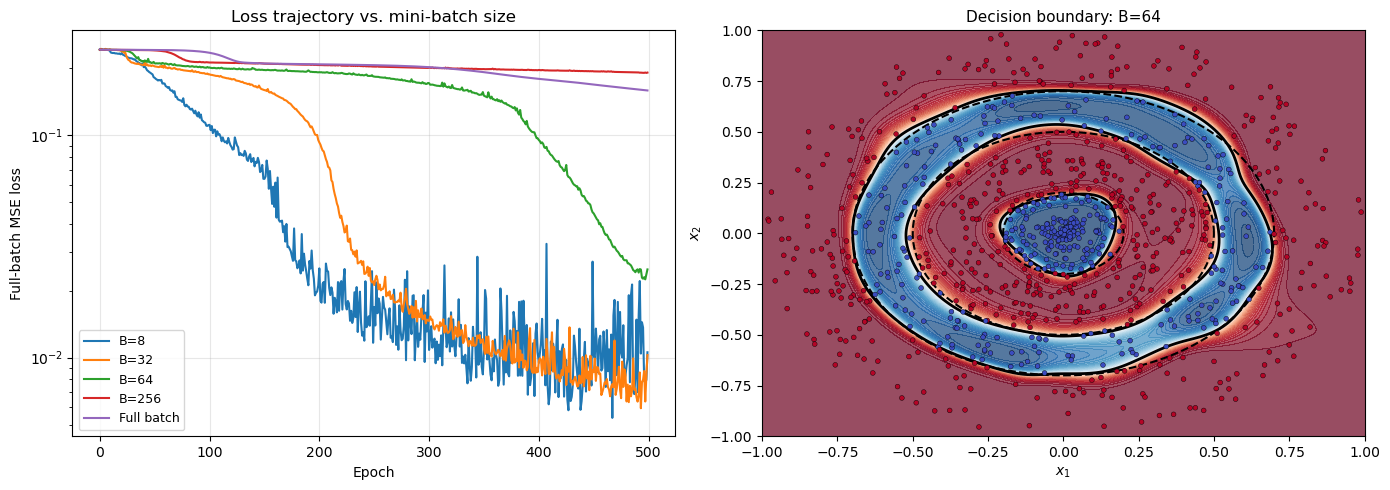

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, (losses, model, c) in results.items():
    axes[0].semilogy(losses, color=c, linewidth=1.5, label=label)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Full-batch MSE loss')
axes[0].set_title('Loss trajectory vs. mini-batch size')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

b_choice = 'B=8'
b_choice = 'B=64'
_, model_chosen, _ = results[b_choice]
pt_decision_boundary(model_chosen, X_big, y_big, axes[1],
                     f'Decision boundary: {b_choice}')
for r in [0.2, 0.5, 0.7]:
    th = np.linspace(0, 2*np.pi, 300)
    axes[1].plot(r*np.cos(th), r*np.sin(th), 'k--', linewidth=1.5)

plt.tight_layout()

Small batches give noisier loss trajectories but can converge faster in wall-clock time (each step is much cheaper). Full-batch gradient descent is smooth but each step processes all data. In practice, $B \in [32, 256]$ is a good starting range; the optimal choice depends on memory constraints, dataset size, and the desired regularization effect.

---
## Summary and Looking Ahead

We built the foundations of deep learning from a single neuron up to mini-batch training, using a single geometric problem as the running thread:

| Component | What it does | Limitation revealed |
|-----------|-------------|--------------------|
| **Perceptron** | Linear boundary | Cannot fit curved/nonlinear regions |
| **Activation function** | Breaks linearity between layers | Saturation → vanishing gradients |
| **Single hidden layer** | Arbitrary nonlinear boundaries | Cannot represent disjoint topology without extreme width |
| **Deep MLP** | Hierarchical, topologically complex boundaries | — |
| **Explicit backprop** | Understand what autograd does | Must rewrite for every architecture |
| **Autograd** | Exact gradients through any computation in one backward pass | — |
| **Training loop** | Forward → loss → backward → step | Need careful data splitting |
| **Mini-batch SGD + Adam** | Scalable, adaptive optimization | Hyperparameter sensitivity |

### Connections to what we've already seen

| Earlier topic | Connection |
|---|---|
| Linear regression | A zero-hidden-layer network; SVD gives the exact solution |
| Gradient descent | The training algorithm — all convergence theory applies |
| ODE systems | Neural ODEs parameterize $\dot{\mathbf{x}} = f(\mathbf{x}; \boldsymbol{\theta})$; PINNs embed PDE residuals in $\mathcal{L}$ |
| SVD / PCA | Autoencoders are the nonlinear generalization of PCA |

### Coming up

- **Convolutional networks and diffusion models** — exploit spatial structure in gridded fields and satellite imagery
- **Recurrent networks and transformers** — for sequences and time series
- **Physics-informed neural networks (PINNs)** — embed ODE/PDE constraints directly in the loss
- **Applications**: emulating climate model parameterizations, detecting tropical cyclones from ERA5 fields, learning dynamical systems from noisy data